In [45]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [46]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [47]:
# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("\n================ DATASET INFORMATION ================")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


================ DATASET INFORMATION ================
Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2 

In [48]:
# ============================================================
# 4. CHECK DATA TYPES
# ============================================================

print("\n================ DATA TYPES ================")

print(df.dtypes)


================ DATA TYPES ================
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [49]:
# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n================ MISSING VALUES ================")

print(df.isnull().sum())


================ MISSING VALUES ================
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [50]:
# ============================================================
# 6. CHECK DUPLICATE ROWS
# ============================================================

print("\n================ DUPLICATES ================")

print("Number of duplicate rows:", df.duplicated().sum())


================ DUPLICATES ================
Number of duplicate rows: 0


In [51]:
# ============================================================
# 7. BASIC STATISTICS
# ============================================================

print("\n================ STATISTICS ================")

print(df.describe())


================ STATISTICS ================
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [52]:
# ============================================================
# 8. CONVERT CATEGORICAL DATA INTO NUMBERS
# ============================================================

categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [53]:
# ============================================================
# 9. CHECK DATA AFTER ENCODING
# ============================================================

print("\n================ AFTER ENCODING ================")

print("New shape:", df.shape)

print("\nColumns after encoding:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


================ AFTER ENCODING ================
New shape: (545, 14)

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

First 5 rows:
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                   

In [54]:
# ============================================================
# 10. CHECK MISSING VALUES AGAIN
# ============================================================

print("\n================ MISSING VALUES AFTER ENCODING ================")

print(df.isnull().sum())


================ MISSING VALUES AFTER ENCODING ================
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
parking                            0
mainroad_yes                       0
guestroom_yes                      0
basement_yes                       0
hotwaterheating_yes                0
airconditioning_yes                0
prefarea_yes                       0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [55]:
# ============================================================
# 11. DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

X = df.drop("price", axis=1)

y = df["price"]


print("\n================ FEATURES AND TARGET ================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("price")


================ FEATURES AND TARGET ================
X shape: (545, 13)
y shape: (545,)

Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Target:
price


In [56]:
# ============================================================
# 12. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n================ TRAIN TEST SPLIT ================")

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


================ TRAIN TEST SPLIT ================
Training data: (436, 13)
Testing data : (109, 13)


                 X + y
              All 545 houses
                    │
                    │
           train_test_split()
                    │
             ┌──────┴──────┐
             │             │
             ▼             ▼
         TRAINING        TESTING
         80%             20%
          │                │
          │                │
     X_train             X_test
     y_train             y_test
          │                │
          ▼                │
    model.fit()             │
          │                │
          ▼                │
    Trained Model            │
          │                │
          └───────┐         │
                  ▼         ▼
             predict(X_test)
                  │
                  ▼
                y_pred
                  │
                  ▼
       Compare y_pred with y_test
                  │
                  ▼
          MAE / RMSE / R²

In [57]:
# ============================================================
# 13. CREATE LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

In [58]:
# ============================================================
# 14. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\n================ MODEL TRAINING ================")

print("Model trained successfully!")


================ MODEL TRAINING ================
Model trained successfully!


In [59]:
# ============================================================
# 15. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


print("\n================ PREDICTIONS ================")

print("First 5 predicted prices:")

print(y_pred[:5])


================ PREDICTIONS ================
First 5 predicted prices:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725956]


In [60]:
# ============================================================
# 16. COMPARE ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Format predicted price
comparison["Predicted Price"] = comparison["Predicted Price"].round(0).astype(int)

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison.head(10).to_string(index=False))


========== ACTUAL VS PREDICTED ==========
 Actual Price  Predicted Price
      4060000          5164654
      6650000          7224722
      3710000          3109863
      6440000          4612075
      2800000          3294646
      4900000          3532275
      5250000          5611775
      4543000          6368146
      2450000          2722857
      3353000          2629406


In [61]:
# ============================================================
# 17. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

In [62]:
# ============================================================
# 18. CALCULATE MSE
# ============================================================

mse = mean_squared_error(y_test, y_pred)

In [63]:
# ============================================================
# 19. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(mse)

In [64]:
# ============================================================
# 20. CALCULATE R2 SCORE
# ============================================================

r2 = r2_score(y_test, y_pred)

In [34]:
# ============================================================
# 21. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n================ MODEL PERFORMANCE ================")

print(f"MAE  : ₹{mae:,.0f}")
print(f"MSE  : {mse:,.0f}")
print(f"RMSE : ₹{rmse:,.0f}")
print(f"R²   : {r2:.3f}")


================ MODEL PERFORMANCE ================
MAE  : ₹970,043
MSE  : 1,754,318,687,331
RMSE : ₹1,324,507
R²   : 0.653


* **MAE** → ₹9.70 lakh  
  └─ *Average error is about ₹9.7 lakh*

* **RMSE** → ₹13.25 lakh  
  └─ *Larger errors are increasing the error*

* **R²** → 0.653  
  └─ *Model explains about 65.3% of price variation*

* **MSE** → 1.754 trillion  
  └─ *Squared-error measure; mainly useful mathematically*


In [65]:
# ============================================================
# 22. MODEL COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)


print("\n================ MODEL COEFFICIENTS ================")

print(coefficients)


================ MODEL COEFFICIENTS ================
                            Feature   Coefficient
2                         bathrooms  1.094445e+06
9               airconditioning_yes  7.914267e+05
8               hotwaterheating_yes  6.846499e+05
10                     prefarea_yes  6.298906e+05
3                           stories  4.074766e+05
7                      basement_yes  3.902512e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
4                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05



| Feature             | Coefficient | Simple meaning                                |
| ------------------- | ----------: | --------------------------------------------- |
| bathrooms           |   +₹10.94 L | 1 more bathroom → higher predicted price      |
| airconditioning_yes |    +₹7.91 L | AC → higher predicted price vs reference      |
| hotwaterheating_yes |    +₹6.85 L | Hot-water heating → higher predicted price    |
| prefarea_yes        |    +₹6.30 L | Preferred area → higher predicted price       |
| stories             |    +₹4.07 L | 1 more story → higher predicted price         |
| basement_yes        |    +₹3.90 L | Basement → higher predicted price             |
| mainroad_yes        |    +₹3.68 L | Main-road access → higher predicted price     |
| guestroom_yes       |    +₹2.32 L | Guestroom → higher predicted price            |
| parking             |    +₹2.25 L | 1 more parking space → higher predicted price |
| bedrooms            |    +₹0.77 L | 1 more bedroom → higher predicted price       |
| area                |  +₹236/unit | 1 more area unit → higher predicted price     |
| semi-furnished      |    -₹1.27 L | Lower predicted price vs reference category   |
| unfurnished         |    -₹4.14 L | Lower predicted price vs reference category   |


In [35]:
# ============================================================
# 24. PREDICT PRICE FOR A NEW HOUSE
# ============================================================

# Create a new house using the SAME feature columns
new_house = pd.DataFrame(
    [[
        6000,   # area
        3,      # bedrooms
        2,      # bathrooms
        2,      # stories
        1,      # parking

        # mainroad_yes
        1,

        # guestroom_yes
        1,

        # basement_yes
        1,

        # hotwaterheating_yes
        0,

        # airconditioning_yes
        1,

        # prefarea_yes
        1,

        # furnishingstatus_semi-furnished
        1,

        # furnishingstatus_unfurnished
        0
    ]],
    columns=X.columns
)


In [36]:

# ============================================================
# 25. PREDICT NEW HOUSE PRICE
# ============================================================

new_price = model.predict(new_house)


print("\n================ NEW HOUSE PREDICTION ================")

print("Predicted house price:", new_price[0])


# ============================================================
# 26. FORMAT PRICE
# ============================================================

print(
    "Predicted price: ₹{:,.2f}".format(new_price[0])
)


================ NEW HOUSE PREDICTION ================
Predicted house price: 7419082.609814318
Predicted price: ₹7,419,082.61


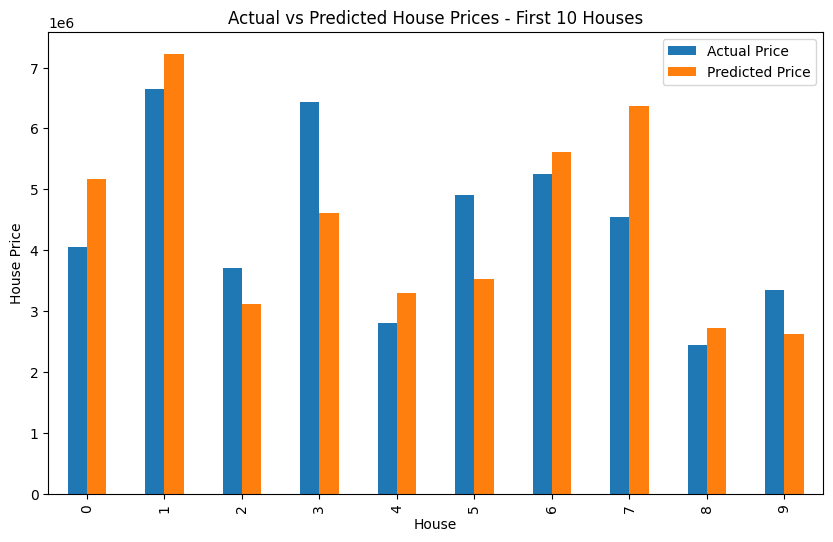

In [67]:
# ============================================================
# 27. ACTUAL VS PREDICTED PRICE - FIRST 10 HOUSES
# ============================================================

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("House")
plt.ylabel("House Price")
plt.title("Actual vs Predicted House Prices - First 10 Houses")

plt.legend(["Actual Price", "Predicted Price"])

plt.show()